(kernels)=

In [1]:
try:
    import smolgp
except ImportError:
    %pip install -q smolgp

try:
    import tinygp
except ImportError:
    %pip install -q tinygp

import jax
import jax.numpy as jnp
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.interpolate import make_smoothing_spline

key = jax.random.PRNGKey(0)
jax.config.update("jax_enable_x64", True)
mpl.rc('font', family='sans serif', size=16)

# Defining Kernels

A number of kernels are pre-defined in `smolgp`, such as the exponential kernel, the Matern family, and the stochastic harmonic oscillator. Let's take a look at some of these to see their covariance structure (and, equivalently, their power spectral densities). First, we define a few functions for plotting:

In [2]:
def plot_psd(kssm, ax=None):
    w = jnp.linspace(0.01, 0.3, 1000)
    S = kssm.psd(w)
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 2))
    ax.plot(w, S, color='k', lw=3)
    ax.set(xlabel=r'$\omega$ [rad/s]', ylabel=r'$S(\omega)$');

def plot_cov(kernel, ax=None, **kwargs):
    dts = jnp.linspace(0, 1000, 500)
    zeros = jnp.zeros_like(dts)
    cov = kernel(zeros, dts)[0,:]
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 2))
    ax.plot(dts, cov, **kwargs)
    ax.set(xlabel=r'$\Delta$ [s]', ylabel=r'$k(t)$');

def plot_psd_and_cov(kssm, kqsm=None, name='Kernel'):
    fig, axes = plt.subplots(1,2, figsize=(12,4))
    fig.suptitle(name)
    plot_psd(kssm, ax=axes[0])
    plot_cov(kssm, ax=axes[1], color='purple', label=r'$k_{SSM}(\Delta)$')
    if kqsm is not None:
        label = 'QSM' if isinstance(kqsm, tinygp.kernels.quasisep.Quasisep) else 'Dense'
        plot_cov(kqsm, ax=axes[1], color='green', label=r'$k_{' + label + '}(\Delta)$', ls='--')
    axes[1].legend(loc='upper right')

## Exponential kernel (aka the Matern-1/2)

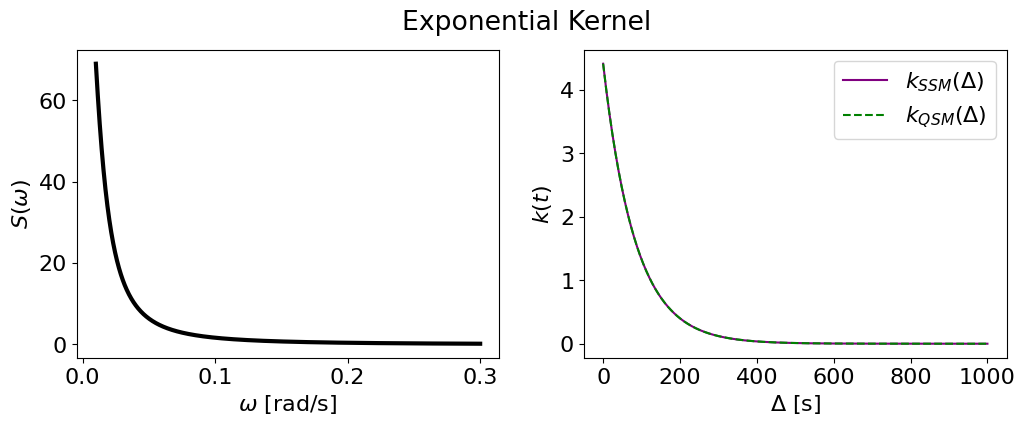

In [3]:
sigma = 2.1
scale = 83.3

exp_smol = smolgp.kernels.Exp(scale=scale, sigma=sigma)
exp_tiny = tinygp.kernels.quasisep.Exp(scale=scale, sigma=sigma)
plot_psd_and_cov(exp_smol, exp_tiny, name='Exponential Kernel')

## Matern-3/2

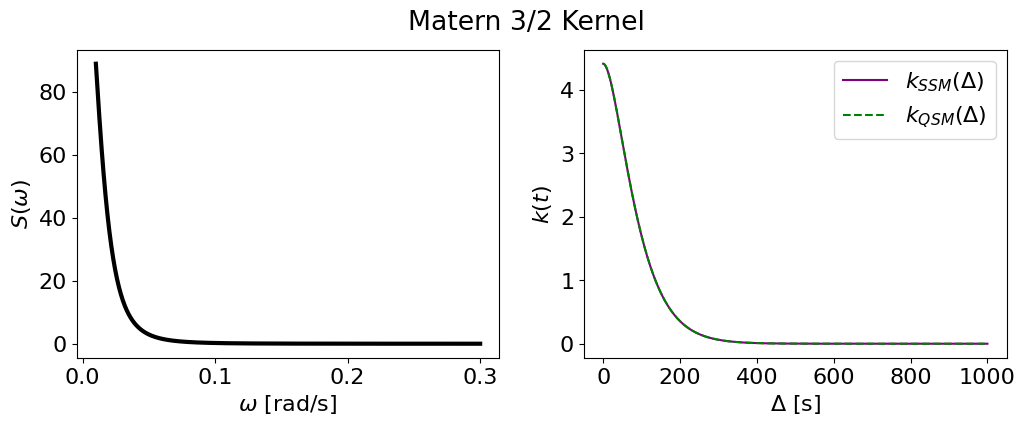

In [4]:
sigma = 2.1
scale = 83.3

m32_smol = smolgp.kernels.Matern32(scale=scale, sigma=sigma)
m32_tiny = tinygp.kernels.quasisep.Matern32(scale=scale, sigma=sigma)
plot_psd_and_cov(m32_smol, m32_tiny, name='Matern 3/2 Kernel')

## Matern-5/2

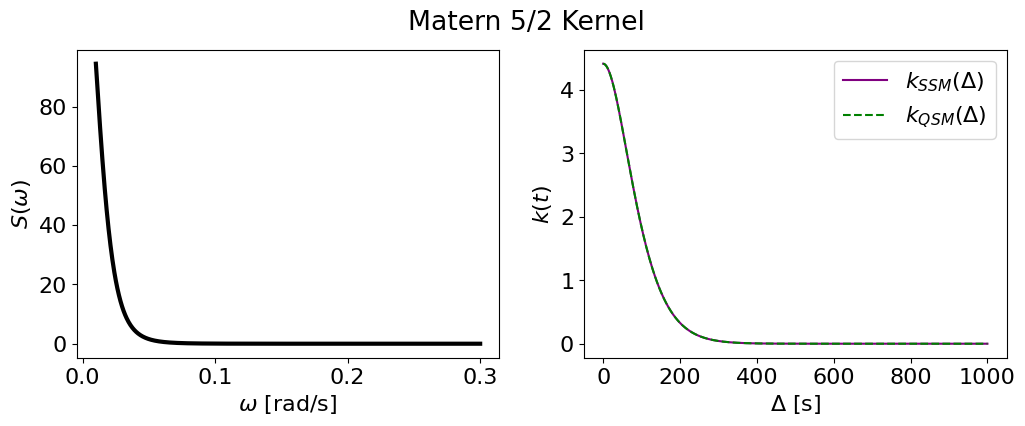

In [5]:
sigma = 2.1
scale = 83.3

m52_smol = smolgp.kernels.Matern52(scale=scale, sigma=sigma)
m52_tiny = tinygp.kernels.quasisep.Matern52(scale=scale, sigma=sigma)
plot_psd_and_cov(m52_smol, m52_tiny, name='Matern 5/2 Kernel')

## Generic half-integer Matern

The generic half-integer Matern kernel is also implemented, though because it relies on a numerical solver to the Lyapunov equation which is only implemented in `scipy` (and not `jax.scipy`), it will not be compatible with JIT/autodiff. This could change if we decide to write a JAX version if some use-case arises.

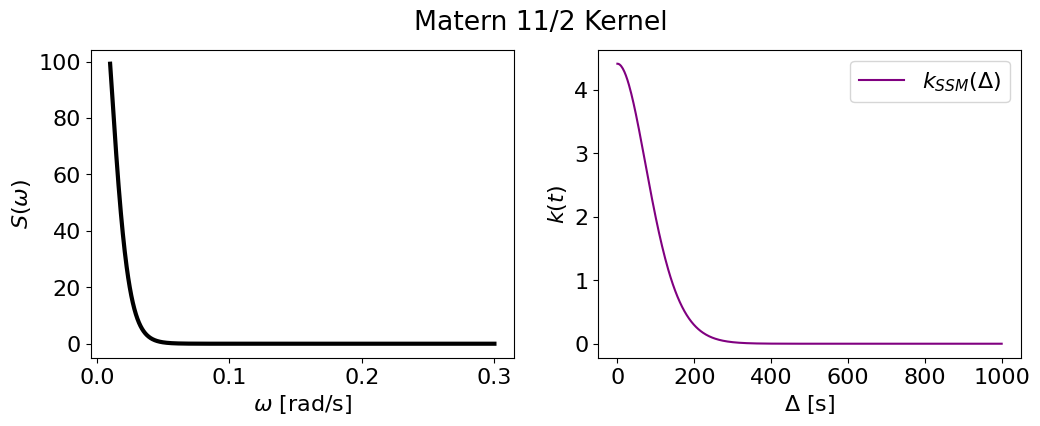

In [6]:
sigma = 2.1
scale = 83.3

m72 = smolgp.kernels.base.Matern(nu=11/2, scale=scale, sigma=sigma)
plot_psd_and_cov(m72, name='Matern 11/2 Kernel')

## SHO

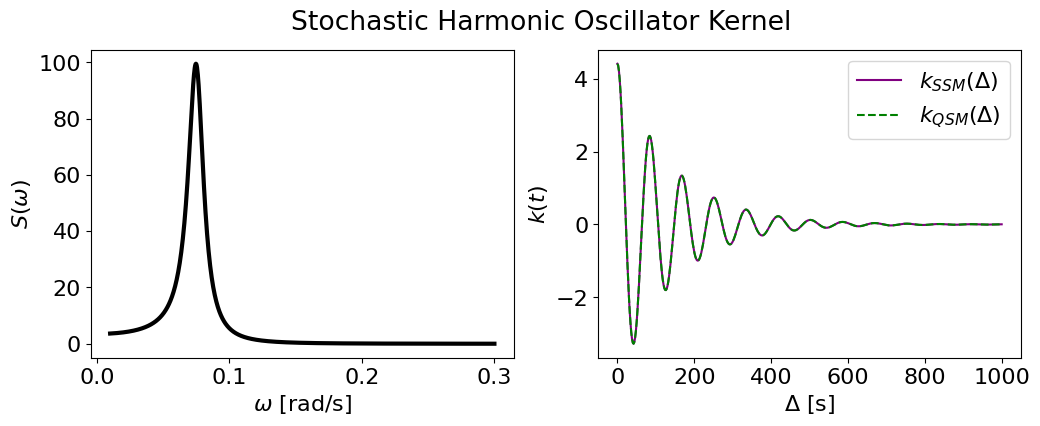

In [7]:
sigma = 2.1
omega = 2*jnp.pi/83.3
quality = 5.3 # underdamped
# quality = 0.5 # critically damped
# quality = 0.1 # overdamped

sho_smol = smolgp.kernels.SHO(omega, quality, sigma)
sho_tiny = tinygp.kernels.quasisep.SHO(omega, quality, sigma)
plot_psd_and_cov(sho_smol, sho_tiny, name='Stochastic Harmonic Oscillator Kernel')

# Arbitrary Kernels

Another benefit of the state space definition is, even for kernels which lack quasiseparability, if a kernel can be represented by a series expansion where each term _does_ have a state space representation, we can build a SSM for an arbitrary kernel to arbitrary precision by summing such terms. An example is the periodic kernel (also called the exponential-sine-squared kernel), which [Solin & Särkkä (2014)](https://proceedings.mlr.press/v33/solin14.html) found a series representation for which we have implemented in `smolgp`. One can multiply this kernel by an exponential kernel to produce a good approximation to the canonical quasiperiodic kernel used throughout astronomy.

One can specify exactly how many terms to include using the `order` keyword, or leave this as `None` to let the code auto-select a reasonable number of terms given the parameter $\ell = \sqrt{2/\Gamma}$ (using Figure 2c of [Solin & Särkkä (2014)](https://proceedings.mlr.press/v33/solin14.html) as a guide).

In [8]:
ell = 1.164 # 0.7
gamma = 2/ell**2
period = 163.3
sigma = 1.0 # tiny version doesn't have a sigma scaling built-in

periodic_smol = smolgp.kernels.ExpSineSquared(gamma=gamma, period=period, sigma=sigma, order=None)
periodic_tiny = tinygp.kernels.ExpSineSquared(gamma=gamma, scale=period)
print(f'Auto-selected {periodic_smol.order} terms based on `gamma`.')

Auto-selected 4 terms based on `gamma`.


We can see exactly what the upper bound on the error in the covariance will be with this many terms:

In [9]:
periodic_smol.error_bound()

Array(0.00584372, dtype=float64, weak_type=True)

The periodic kernel will not have a defined PSD, as it is defined from the sum of terms with zero process noise. In other words, the PSD is not a continuous rational function but a sum of weighted Dirac delta functions (poles); this is precisely why it does not have its own quasiseparable or state space definition.

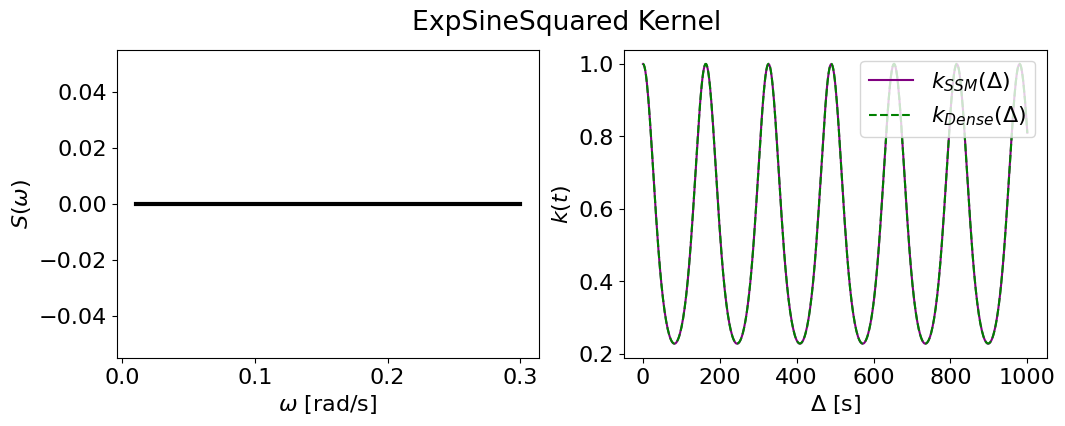

In [10]:
plot_psd_and_cov(periodic_smol, periodic_tiny, name='ExpSineSquared Kernel')

We can verify the error in our approximation is well below that error bound:

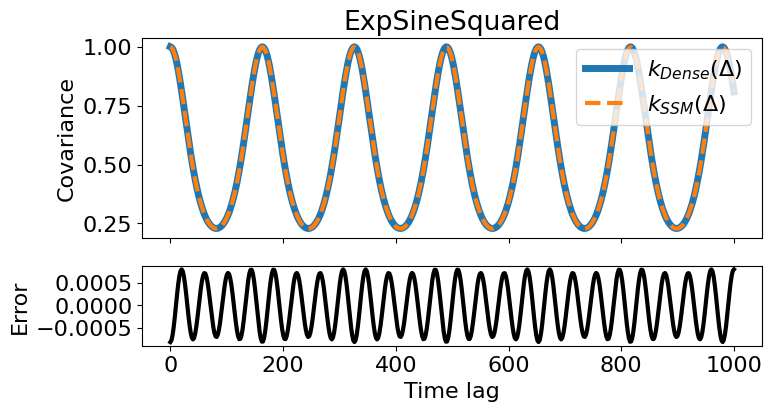

In [11]:
dts = jnp.linspace(0, 1000, 500)
zeros = jnp.zeros_like(dts)

cov_tiny = periodic_tiny(zeros, dts)[0,:]
cov_smol = periodic_smol(zeros, dts)[0,:]
res_cov = cov_smol - cov_tiny

fig, (ax, rax) = plt.subplots(2, 1, figsize=(8,4), sharex=True, gridspec_kw={'height_ratios': [3, 1.2]})
ax.set_title(f'{periodic_smol.__class__.__name__}')
ax.plot(dts, cov_tiny, label=r'$k_{Dense}(\Delta)$', lw=5, color='C0')
ax.plot(dts, cov_smol, label=r'$k_{SSM}(\Delta)$', lw=3, color='C1', ls='--')
ax.set_ylabel('Covariance'); ax.legend(loc='upper right')
eps = jnp.spacing(cov_tiny)
rax.plot(dts, res_cov, lw=3, color='k')
rax.set_ylabel('Error'); rax.set_xlabel('Time lag');

## Verifying the likelihood, conditioning, and predictions for the ExpSineSquared kernel

Let's generate some mock data from a periodic process and run through the full GP regression to see how well we do with our approximated SSM definition.

In [12]:
from scipy.interpolate import make_smoothing_spline

def get_true_tiny(true_kernel, tmin=0, tmax=1000, dt=1):
    t = jnp.arange(tmin, tmax, dt)
    true_gp = tinygp.GaussianProcess(true_kernel, t)
    # gp.sample adds small random noise for numerical stability
    y_sample = true_gp.sample(key=jax.random.PRNGKey(32)) 
    f = make_smoothing_spline(t, y_sample, lam=dt/6)
    return t, f

## True process
t_true, f = get_true_tiny(periodic_tiny, tmin=0, tmax=1000, dt=1)
y_true = f(t_true)

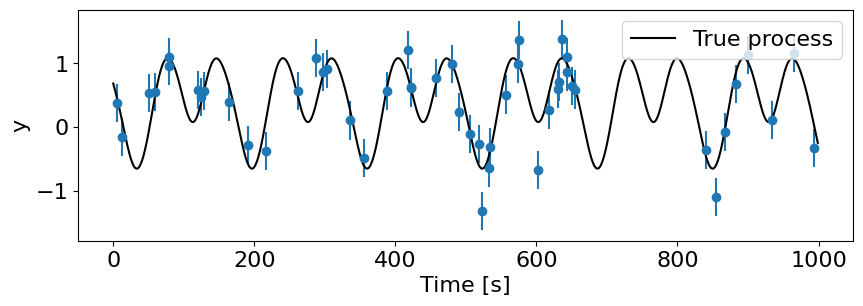

In [13]:
## Mock data
t_train  = jnp.sort(jax.random.uniform(key, (50,), minval=0, maxval=1000))
yerr = 0.3 * jnp.ones_like(t_train)
y_train = f(t_train) + yerr * jax.random.normal(key, t_train.shape)

# Define the GPs
gp_smol = smolgp.GaussianProcess(kernel=periodic_smol, X=t_train, diag=yerr**2)
gp_tiny = tinygp.GaussianProcess(kernel=periodic_tiny, X=t_train, diag=yerr**2)

# Plot the data and true process
plt.figure(figsize=(10, 3))
plt.errorbar(t_train, y_train, yerr=yerr, fmt="o", markeredgecolor='C0', markersize=6, capsize=0)
plt.plot(t_true, y_true, "-k", label="True process")
plt.xlabel('Time [s]'); plt.ylabel('y'); plt.legend(loc='upper right');

In [22]:
offset = jnp.finfo(jnp.array(0.)).eps

print(f'Testing {periodic_smol.name}\n')

## Likelihoods
print('Log-likelihoods:')
llh_smol = gp_smol.log_probability(y_train)
llh_tiny = gp_tiny.log_probability(y_train)
llh_diff = llh_smol - llh_tiny
print(f"   smolgp: {llh_smol:f}")
print(f"   tinygp: {llh_tiny:f}")
print(f"   Difference: {llh_diff:.3e}  ({llh_diff/llh_tiny*100:.1f}%)")

## Conditioning
print('\nConditioning GPs on data...')
llh_tiny2, condGP_tiny = gp_tiny.condition(y_train, t_train)
llh_smol2, condGP_smol = gp_smol.condition(y_train)
mean_diff = condGP_tiny.loc - condGP_smol.loc
var_diff  = (condGP_tiny.variance-offset) - condGP_smol.variance
print(f'   Mean max abs diff: {jnp.max(jnp.abs(mean_diff)):.3e}  ({jnp.max(jnp.abs(mean_diff))/jnp.max(jnp.abs(condGP_smol.loc))*100:.1f}%)')
print(f'   Variance max abs diff: {jnp.max(jnp.abs(var_diff)):.3e}  ({jnp.max(jnp.abs(var_diff))/jnp.max(jnp.abs(condGP_smol.variance))*100:.1f}%)')

## Predictions
print('\nPredictions at new points:')
t_test = jnp.linspace(0, 1000, 1000)
mu_tiny, var_tiny = gp_tiny.predict(y_train, t_test, return_var=True)
mu_smol, var_smol = condGP_smol.predict(t_test, return_var=True)
pred_mean_diff = mu_tiny - mu_smol
pred_var_diff  = (var_tiny - offset) - var_smol
print(f'   Mean max abs diff: {jnp.max(jnp.abs(pred_mean_diff)):.3e}  ({jnp.max(jnp.abs(pred_mean_diff))/jnp.max(jnp.abs(mu_smol))*100:.1f}%)')
print(f'   Variance max abs diff: {jnp.max(jnp.abs(pred_var_diff)):.3e}  ({jnp.max(jnp.abs(pred_var_diff))/jnp.max(jnp.abs(var_smol))*100:.1f}%)')

Testing ExpSineSquared

Log-likelihoods:
   smolgp: -23.057054
   tinygp: -23.113743
   Difference: 5.669e-02  (-0.2%)

Conditioning GPs on data...
   Mean max abs diff: 1.573e-02  (1.4%)
   Variance max abs diff: 1.541e-03  (9.4%)

Predictions at new points:
   Mean max abs diff: 1.583e-02  (1.4%)
   Variance max abs diff: 1.748e-03  (10.0%)


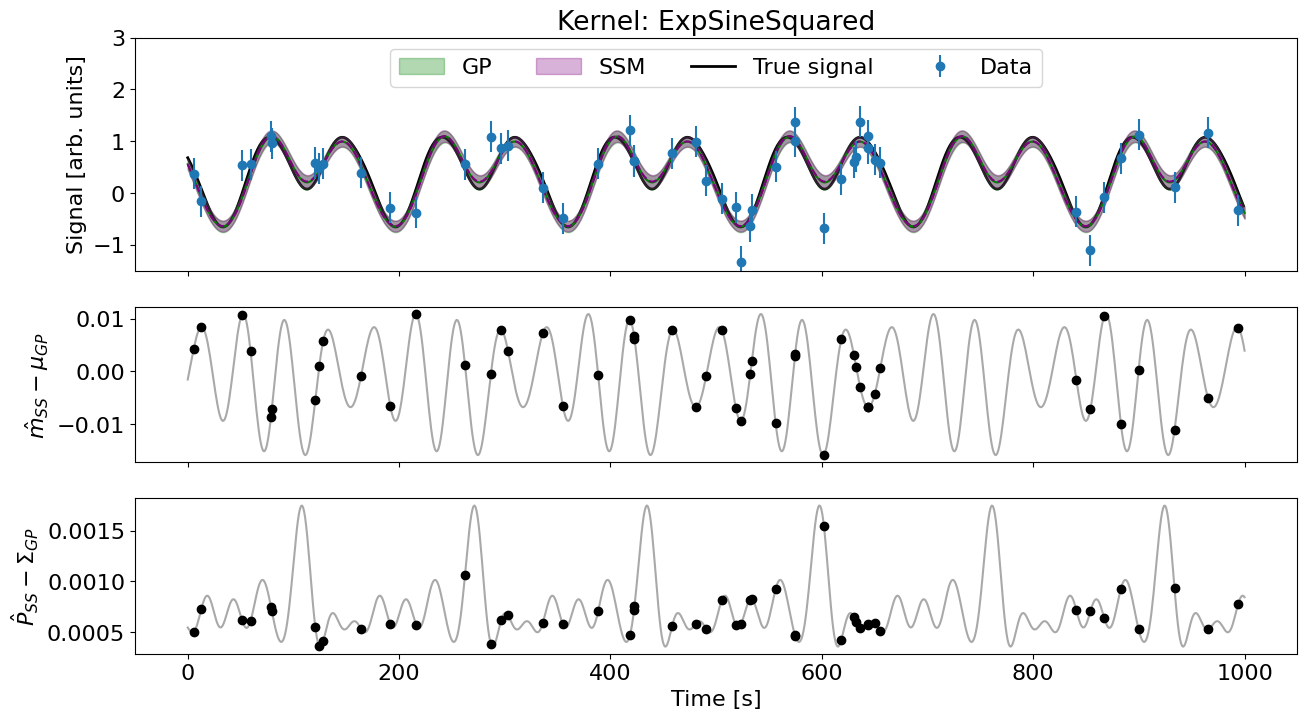

In [23]:
## Plot
fig, (ax, rax, rrax) = plt.subplots(3,1, figsize=(15,8), sharex=True,
                                    gridspec_kw={'height_ratios':[1.5,1,1]})

## Predictions
ax.plot(t_test, mu_tiny, color='green')
ax.plot(t_test, mu_smol, color='purple', ls='--')
ax.fill_between(t_test, mu_tiny-jnp.sqrt(var_tiny), mu_tiny+jnp.sqrt(var_tiny), alpha=0.3, color='green', label='GP')
ax.fill_between(t_test, mu_smol-jnp.sqrt(var_smol), mu_smol+jnp.sqrt(var_smol), alpha=0.3, color='purple', label='SSM')
ax.set(ylabel='Signal [arb. units]', title=f'Kernel: {periodic_smol.name}', ylim=[-1.5,3])

## Data and true signal
ax.plot(t_true, y_true, label='True signal', color='k', lw=2, zorder=-10)
ax.errorbar(t_train, y_train, yerr, fmt='o', color='C0', label='Data', alpha=1)
ax.legend(ncol=4, loc='upper center')

## Mean residuals
rax.scatter(t_train, mean_diff, color='k', zorder=100)
rax.plot(t_test, pred_mean_diff, color='darkgrey')
rax.set(ylabel=r'$\hat{m}_{SS}- \mu_{GP}$')

## Var residuals
rrax.scatter(t_train, var_diff, color='k', zorder=100)
rrax.plot(t_test, pred_var_diff, color='darkgrey')
rrax.set(ylabel=r'$\hat{P}_{SS}- \Sigma_{GP}$')
rrax.set_xlabel('Time [s]');

Pretty good for all intents and purposes!

## Other kernels

Other kernels may be implemented in the future, such as an approximation to the RBF kernel (also called the squared-exponential kernel) as described by [Hartikainen & Särkkä (2010)](https://users.aalto.fi/~ssarkka/pub/gp-ts-kfrts.pdf). Raise a Github issue (or a pull request 😉) if you'd like that functionality.